# AAI 511 Final Team Project: Data Engineering and Preprocessing

This notebook prepares the MIDI composer dataset for the LSTM and CNN model notebooks. It filters the dataset to the four required composers, checks file quality, extracts MIDI features, creates visualizations, and saves model-ready files for the team.

## 1. Install Libraries

These libraries are used to read MIDI files, create piano-roll matrices, split the data, and build charts.

In [ ]:
!pip install music21 pretty_midi matplotlib pandas numpy scikit-learn tqdm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 67.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 5.4 MB/s eta 0:00:00


## 2. Imports and Settings

All main settings are kept in one place so the team can adjust them later if needed.

In [ ]:
import os
import json
import random
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

from music21 import converter, note, chord, tempo
import pretty_midi

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)

TARGET_COMPOSERS = ['Bach', 'Beethoven', 'Chopin', 'Mozart']

# LSTM settings
SEQUENCE_LENGTH = 100
LSTM_STEP = 10

# CNN piano-roll settings
PIANO_ROLL_FS = 10
PIANO_ROLL_FRAMES = 128

# Split settings
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15
RANDOM_STATE = 42

print('Settings loaded.')
print('Target composers:', TARGET_COMPOSERS)
print(f'LSTM window: {SEQUENCE_LENGTH} events, step {LSTM_STEP}')
print(f'CNN piano-roll shape: 128 x {PIANO_ROLL_FRAMES}')

## 3. Connect to Google Drive and Find the Dataset

This notebook is set up to work for Ahmed and the team.

Put the unzipped dataset in one of these locations in **My Drive**:

`AAI511_TM1/midi_dataset` or `AAI-511-Group 4/midi_dataset`

Inside `midi_dataset`, there should be four folders: `Bach`, `Beethoven`, `Chopin`, and `Mozart`. The notebook will check the folders and then save the processed files into a `processed_data` folder next to the dataset.

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive', force_remount=True)

# This cell is team-friendly. It checks the common project folders first,
# then searches My Drive for a folder named midi_dataset.
MY_DRIVE_ROOT = '/content/drive/MyDrive'
PROJECT_FOLDER_CANDIDATES = [
    'AAI511_TM1',        # simple personal/team folder option
    'AAI-511-Group 4'   # shared folder shortcut option
]

REQUIRED_COMPOSER_FOLDERS = TARGET_COMPOSERS


def is_valid_dataset_folder(path):
    """Return True only if the path has all four required composer folders."""
    if not os.path.isdir(path):
        return False
    return all(os.path.isdir(os.path.join(path, composer)) for composer in REQUIRED_COMPOSER_FOLDERS)


def find_dataset_folder():
    """Find midi_dataset in the expected project folders or by searching My Drive."""
    checked_paths = []

    # First check the expected folder names.
    for folder_name in PROJECT_FOLDER_CANDIDATES:
        candidate = os.path.join(MY_DRIVE_ROOT, folder_name, 'midi_dataset')
        checked_paths.append(candidate)
        if is_valid_dataset_folder(candidate):
            return candidate, checked_paths

    # Backup search. This helps if a teammate names the project folder differently.
    print('Expected folders not found. Searching My Drive for midi_dataset...')
    skip_dirs = {'processed_data', '__MACOSX', '.ipynb_checkpoints'}

    for root, dirs, files in os.walk(MY_DRIVE_ROOT):
        # Keep the search cleaner and avoid output/system folders.
        dirs[:] = [d for d in dirs if d not in skip_dirs and not d.startswith('._')]

        if os.path.basename(root) == 'midi_dataset' and is_valid_dataset_folder(root):
            return root, checked_paths

    return None, checked_paths


DATA_ROOT, checked_paths = find_dataset_folder()

if DATA_ROOT is None:
    print('\nChecked these expected paths:')
    for p in checked_paths:
        print('-', p)

    print('\nFolders currently visible in My Drive:')
    print(os.listdir(MY_DRIVE_ROOT)[:50])

    raise FileNotFoundError(
        'Could not find a valid midi_dataset folder.\n\n'
        'Use this structure in Google Drive:\n'
        'My Drive/AAI511_TM1/midi_dataset/Bach\n'
        'My Drive/AAI511_TM1/midi_dataset/Beethoven\n'
        'My Drive/AAI511_TM1/midi_dataset/Chopin\n'
        'My Drive/AAI511_TM1/midi_dataset/Mozart\n\n'
        'Or use the shared folder shortcut:\n'
        'My Drive/AAI-511-Group 4/midi_dataset/Bach, Beethoven, Chopin, Mozart'
    )

BASE_DIR = os.path.dirname(DATA_ROOT)
OUTPUT_DIR = os.path.join(BASE_DIR, 'processed_data')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Project folder:', BASE_DIR)
print('Dataset folder:', DATA_ROOT)
print('Output folder :', OUTPUT_DIR)
print('\nDataset folder contents:')
print(os.listdir(DATA_ROOT))


## 4. Dataset Exploration

This section scans the four composer folders and counts MIDI files. The search is recursive, so it also finds MIDI files inside nested folders.

In [ ]:
def collect_midi_files(data_root, composers):
    records = []

    for composer in composers:
        composer_path = os.path.join(data_root, composer)

        if not os.path.exists(composer_path):
            print(f'Warning: folder not found for {composer}')
            continue

        for root, dirs, files in os.walk(composer_path):
            # Ignore Mac metadata folders if they appear
            dirs[:] = [d for d in dirs if d != '__MACOSX' and not d.startswith('._')]

            for filename in files:
                lower_name = filename.lower()
                if lower_name.startswith('._') or lower_name == '.ds_store':
                    continue

                if lower_name.endswith(('.mid', '.midi')):
                    records.append({
                        'filepath': os.path.join(root, filename),
                        'filename': filename,
                        'composer': composer
                    })

    return pd.DataFrame(records)


df_files = collect_midi_files(DATA_ROOT, TARGET_COMPOSERS)

if df_files.empty:
    raise ValueError('No MIDI files were found. Check DATA_ROOT and folder names.')

display(df_files.head())

summary_counts = (
    df_files.groupby('composer')
    .size()
    .reindex(TARGET_COMPOSERS, fill_value=0)
    .reset_index(name='total_midi_files')
)

display(summary_counts)
print(f'Total MIDI files found: {len(df_files)}')

## 4.1 Composer Distribution Chart

This chart helps show whether the dataset is balanced across the four composers.

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(summary_counts['composer'], summary_counts['total_midi_files'])
plt.title('MIDI File Count by Composer')
plt.xlabel('Composer')
plt.ylabel('Number of MIDI Files')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'composer_distribution.png'), dpi=150)
plt.show()

## 5. Data Cleaning

This step checks whether each MIDI file can be opened and whether it contains notes or chords. Files that cannot be parsed are removed from the clean file list.

In [ ]:
def is_valid_midi(filepath):
    try:
        stream = converter.parse(filepath)
        elements = stream.recurse().notes
        note_count = sum(1 for el in elements if isinstance(el, (note.Note, chord.Chord)))
        return note_count > 0
    except Exception:
        return False


print('Checking MIDI files. This may take several minutes...')
valid_flags = []

for fp in tqdm(df_files['filepath'], desc='Validating MIDI files'):
    valid_flags.append(is_valid_midi(fp))

df_files['valid'] = valid_flags
df_clean = df_files[df_files['valid']].reset_index(drop=True)

clean_summary = (
    df_files.groupby('composer')
    .agg(total_files=('filepath', 'count'), valid_files=('valid', 'sum'))
    .reindex(TARGET_COMPOSERS)
    .reset_index()
)
clean_summary['removed_files'] = clean_summary['total_files'] - clean_summary['valid_files']

display(clean_summary)

if df_clean.empty:
    raise ValueError('No valid MIDI files remained after cleaning.')

## 6. Train, Validation, and Test Split

The split is done at the **file level** before creating LSTM windows. This avoids data leakage, so parts of the same MIDI file do not appear in both training and testing.

In [ ]:
def stratified_file_split(df, train=0.70, val=0.15, seed=42):
    test = 1.0 - train - val

    df_train, df_temp = train_test_split(
        df,
        test_size=(val + test),
        stratify=df['composer'],
        random_state=seed
    )

    relative_test = test / (val + test)

    df_val, df_test = train_test_split(
        df_temp,
        test_size=relative_test,
        stratify=df_temp['composer'],
        random_state=seed
    )

    return (
        df_train.reset_index(drop=True),
        df_val.reset_index(drop=True),
        df_test.reset_index(drop=True)
    )


df_train, df_val, df_test = stratified_file_split(
    df_clean,
    train=TRAIN_RATIO,
    val=VAL_RATIO,
    seed=RANDOM_STATE
)

df_train['split'] = 'train'
df_val['split'] = 'val'
df_test['split'] = 'test'

df_splits = pd.concat([df_train, df_val, df_test], ignore_index=True)
df_splits.to_csv(os.path.join(OUTPUT_DIR, 'file_level_splits.csv'), index=False)

split_table = (
    df_splits.groupby(['split', 'composer'])
    .size()
    .unstack(fill_value=0)
    .reindex(index=['train', 'val', 'test'])
    .reindex(columns=TARGET_COMPOSERS)
)

display(split_table)
print('File-level split saved.')

## 7. Feature Extraction Functions

The LSTM model needs note and chord sequences. The CNN model needs piano-roll matrices. This section creates both formats from each MIDI file.

In [ ]:
def extract_note_features(filepath):
    try:
        stream = converter.parse(filepath)
        elements = stream.recurse().notes

        sequence = []
        pitches = []
        total_duration = 0.0

        for el in elements:
            if isinstance(el, note.Note):
                sequence.append(str(el.pitch))
                pitches.append(int(el.pitch.midi))
                total_duration += float(el.duration.quarterLength)

            elif isinstance(el, chord.Chord):
                chord_pitches = sorted([int(p.midi) for p in el.pitches])
                chord_token = '.'.join(str(p) for p in chord_pitches)
                sequence.append(chord_token)
                pitches.extend(chord_pitches)
                total_duration += float(el.duration.quarterLength)

        tempo_marks = stream.flatten().getElementsByClass(tempo.MetronomeMark)
        bpm_values = [tm.number for tm in tempo_marks if tm.number is not None]
        bpm = float(bpm_values[0]) if bpm_values else 120.0

        mean_pitch = float(np.mean(pitches)) if pitches else np.nan
        mean_pitch_norm = mean_pitch / 127.0 if pitches else np.nan

        return {
            'sequence': sequence,
            'pitches': pitches,
            'tempo_bpm': bpm,
            'duration_ql': total_duration,
            'sequence_length': len(sequence),
            'mean_pitch': mean_pitch,
            'mean_pitch_norm': mean_pitch_norm
        }

    except Exception:
        return None


def extract_piano_roll(filepath, fs=PIANO_ROLL_FS, max_frames=PIANO_ROLL_FRAMES):
    try:
        pm = pretty_midi.PrettyMIDI(filepath)
        roll = pm.get_piano_roll(fs=fs)

        # Normalize to binary note activity. This gives the CNN a clean 0/1 input matrix.
        roll = (roll > 0).astype(np.float32)

        if roll.shape[1] >= max_frames:
            return roll[:, :max_frames]

        pad = np.zeros((128, max_frames - roll.shape[1]), dtype=np.float32)
        return np.concatenate([roll, pad], axis=1)

    except Exception:
        return None


print('Feature extraction functions ready.')

## 8. Extract Features by Split

This section creates one feature record per MIDI file. If a file fails during feature extraction, it is skipped and counted.

In [ ]:
def process_split(df_split, split_name):
    records = []
    skipped = 0

    print(f'Processing {split_name} split...')

    for _, row in tqdm(df_split.iterrows(), total=len(df_split), desc=split_name):
        note_features = extract_note_features(row['filepath'])
        piano_roll = extract_piano_roll(row['filepath'])

        if note_features is None or piano_roll is None or len(note_features['sequence']) == 0:
            skipped += 1
            continue

        records.append({
            'filepath': row['filepath'],
            'filename': row['filename'],
            'composer': row['composer'],
            'split': split_name,
            'sequence': note_features['sequence'],
            'pitches': note_features['pitches'],
            'piano_roll': piano_roll,
            'tempo_bpm': note_features['tempo_bpm'],
            'duration_ql': note_features['duration_ql'],
            'sequence_length': note_features['sequence_length'],
            'mean_pitch': note_features['mean_pitch'],
            'mean_pitch_norm': note_features['mean_pitch_norm']
        })

    print(f'{split_name}: {len(records)} processed, {skipped} skipped')
    return records


train_records = process_split(df_train, 'train')
val_records = process_split(df_val, 'val')
test_records = process_split(df_test, 'test')

all_records = train_records + val_records + test_records

if len(all_records) == 0:
    raise ValueError('No feature records were created.')

feature_summary = pd.DataFrame([
    {
        'filepath': r['filepath'],
        'filename': r['filename'],
        'composer': r['composer'],
        'split': r['split'],
        'sequence_length': r['sequence_length'],
        'tempo_bpm': r['tempo_bpm'],
        'duration_ql': r['duration_ql'],
        'mean_pitch': r['mean_pitch'],
        'mean_pitch_norm': r['mean_pitch_norm']
    }
    for r in all_records
])

feature_summary.to_csv(os.path.join(OUTPUT_DIR, 'feature_summary.csv'), index=False)

display(feature_summary.head())
print(f'Total feature records: {len(feature_summary)}')

## 9. Sequence Length and Tempo Summary

These statistics help explain the dataset in the final report.

In [ ]:
print('Sequence length summary by composer:')
display(feature_summary.groupby('composer')['sequence_length'].describe().round(2))

print('Tempo summary by composer:')
display(feature_summary.groupby('composer')['tempo_bpm'].describe().round(2))

plt.figure(figsize=(9, 5))
feature_summary.boxplot(column='sequence_length', by='composer', grid=False)
plt.axhline(SEQUENCE_LENGTH, linestyle='--', linewidth=1.2)
plt.title('Sequence Length by Composer')
plt.suptitle('')
plt.xlabel('Composer')
plt.ylabel('Number of Note or Chord Events')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'sequence_length_by_composer.png'), dpi=150)
plt.show()

plt.figure(figsize=(9, 5))
plt.hist(feature_summary['sequence_length'], bins=40)
plt.axvline(SEQUENCE_LENGTH, linestyle='--', linewidth=1.2)
plt.title('Overall Sequence Length Distribution')
plt.xlabel('Number of Note or Chord Events')
plt.ylabel('File Count')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'sequence_length_distribution.png'), dpi=150)
plt.show()

## 10. Note Frequency Visualization

This chart shows the most common individual notes for each composer. Chord tokens are excluded from this plot to keep the chart readable.

In [ ]:
def get_top_notes(records, composer, n=15):
    tokens = []
    for r in records:
        if r['composer'] == composer:
            for token in r['sequence']:
                if '.' not in token:
                    tokens.append(token)
    return Counter(tokens).most_common(n)


fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, composer in zip(axes.flat, TARGET_COMPOSERS):
    data = get_top_notes(all_records, composer)

    if not data:
        ax.set_title(f'{composer}: no data')
        continue

    notes, counts = zip(*data)
    ax.barh(notes[::-1], counts[::-1])
    ax.set_title(composer)
    ax.set_xlabel('Frequency')

plt.suptitle('Top 15 Notes per Composer')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'note_frequency_by_composer.png'), dpi=150)
plt.show()

## 11. Sample Piano-Roll Visualization

A piano-roll is a matrix where rows represent MIDI pitches and columns represent time frames. This is the input format prepared for the CNN model.

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

for ax, composer in zip(axes.flat, TARGET_COMPOSERS):
    sample = next((r for r in all_records if r['composer'] == composer), None)

    if sample is None:
        ax.set_title(f'{composer}: no data')
        continue

    roll = sample['piano_roll']
    ax.imshow(roll[36:96, :], aspect='auto', origin='lower', interpolation='nearest')
    ax.set_title(composer)
    ax.set_xlabel('Time Frame')
    ax.set_ylabel('MIDI Pitch Range 36 to 96')

plt.suptitle('Sample Piano-Roll Matrix per Composer')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'sample_piano_rolls.png'), dpi=150)
plt.show()

## 12. Build LSTM Inputs

The LSTM model uses integer-encoded note and chord sequences. The windows are created **after** the file-level split to avoid leakage between training and testing.

In [ ]:
all_tokens = []
for r in train_records:
    all_tokens.extend(r['sequence'])

# Reserve 0 for unknown or padding if needed later.
vocab = sorted(set(all_tokens))
token_to_int = {token: idx + 1 for idx, token in enumerate(vocab)}

print(f'Vocabulary size from training data: {len(token_to_int)}')


def make_lstm_windows(records, token_to_int, seq_len=SEQUENCE_LENGTH, step=LSTM_STEP):
    X = []
    y = []

    for r in records:
        encoded = [token_to_int.get(token, 0) for token in r['sequence']]

        if len(encoded) < seq_len:
            continue

        for start in range(0, len(encoded) - seq_len + 1, step):
            X.append(encoded[start:start + seq_len])
            y.append(r['composer'])

    if len(X) == 0:
        return np.empty((0, seq_len), dtype=np.int32), np.array([], dtype=object)

    return np.array(X, dtype=np.int32), np.array(y)


X_seq_train, y_seq_train_labels = make_lstm_windows(train_records, token_to_int)
X_seq_val, y_seq_val_labels = make_lstm_windows(val_records, token_to_int)
X_seq_test, y_seq_test_labels = make_lstm_windows(test_records, token_to_int)

print('LSTM shapes:')
print('Train:', X_seq_train.shape, Counter(y_seq_train_labels))
print('Val  :', X_seq_val.shape, Counter(y_seq_val_labels))
print('Test :', X_seq_test.shape, Counter(y_seq_test_labels))

if X_seq_train.shape[0] == 0:
    raise ValueError('No LSTM training windows were created. Try reducing SEQUENCE_LENGTH.')

## 13. Build CNN Inputs

The CNN model uses one piano-roll matrix per MIDI file. The values are binary, where 1 means a pitch is active at that time frame.

In [ ]:
def make_cnn_arrays(records):
    X = []
    y = []

    for r in records:
        X.append(r['piano_roll'])
        y.append(r['composer'])

    X = np.stack(X, axis=0).astype(np.float32)
    X = X[:, :, :, np.newaxis]
    y = np.array(y)

    return X, y


X_cnn_train, y_cnn_train_labels = make_cnn_arrays(train_records)
X_cnn_val, y_cnn_val_labels = make_cnn_arrays(val_records)
X_cnn_test, y_cnn_test_labels = make_cnn_arrays(test_records)

print('CNN shapes:')
print('Train:', X_cnn_train.shape, Counter(y_cnn_train_labels))
print('Val  :', X_cnn_val.shape, Counter(y_cnn_val_labels))
print('Test :', X_cnn_test.shape, Counter(y_cnn_test_labels))

## 14. Encode Labels and Save Outputs

The labels are encoded consistently for both models:

0 = Bach  
1 = Beethoven  
2 = Chopin  
3 = Mozart

In [ ]:
label_encoder = LabelEncoder()
label_encoder.fit(TARGET_COMPOSERS)

y_seq_train = label_encoder.transform(y_seq_train_labels)
y_seq_val = label_encoder.transform(y_seq_val_labels)
y_seq_test = label_encoder.transform(y_seq_test_labels)

y_cnn_train = label_encoder.transform(y_cnn_train_labels)
y_cnn_val = label_encoder.transform(y_cnn_val_labels)
y_cnn_test = label_encoder.transform(y_cnn_test_labels)

print('Label encoding:')
for composer, encoded_value in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)):
    print(f'{encoded_value}: {composer}')

# Save LSTM arrays
np.save(os.path.join(OUTPUT_DIR, 'X_seq_train.npy'), X_seq_train)
np.save(os.path.join(OUTPUT_DIR, 'X_seq_val.npy'), X_seq_val)
np.save(os.path.join(OUTPUT_DIR, 'X_seq_test.npy'), X_seq_test)
np.save(os.path.join(OUTPUT_DIR, 'y_seq_train.npy'), y_seq_train)
np.save(os.path.join(OUTPUT_DIR, 'y_seq_val.npy'), y_seq_val)
np.save(os.path.join(OUTPUT_DIR, 'y_seq_test.npy'), y_seq_test)

# Save CNN arrays
np.save(os.path.join(OUTPUT_DIR, 'X_cnn_train.npy'), X_cnn_train)
np.save(os.path.join(OUTPUT_DIR, 'X_cnn_val.npy'), X_cnn_val)
np.save(os.path.join(OUTPUT_DIR, 'X_cnn_test.npy'), X_cnn_test)
np.save(os.path.join(OUTPUT_DIR, 'y_cnn_train.npy'), y_cnn_train)
np.save(os.path.join(OUTPUT_DIR, 'y_cnn_val.npy'), y_cnn_val)
np.save(os.path.join(OUTPUT_DIR, 'y_cnn_test.npy'), y_cnn_test)

# Save metadata
with open(os.path.join(OUTPUT_DIR, 'token_to_int.json'), 'w') as f:
    json.dump(token_to_int, f, indent=2)

np.save(os.path.join(OUTPUT_DIR, 'label_classes.npy'), label_encoder.classes_)

dataset_summary = {
    'target_composers': TARGET_COMPOSERS,
    'total_raw_midi_files': int(len(df_files)),
    'valid_midi_files': int(len(df_clean)),
    'total_feature_records': int(len(all_records)),
    'lstm_sequence_length': SEQUENCE_LENGTH,
    'lstm_step': LSTM_STEP,
    'cnn_piano_roll_shape': [128, PIANO_ROLL_FRAMES, 1],
    'train_ratio': TRAIN_RATIO,
    'val_ratio': VAL_RATIO,
    'test_ratio': TEST_RATIO,
    'label_encoding': {cls: int(label_encoder.transform([cls])[0]) for cls in label_encoder.classes_}
}

with open(os.path.join(OUTPUT_DIR, 'dataset_summary.json'), 'w') as f:
    json.dump(dataset_summary, f, indent=2)

print('Saved files:')
for filename in sorted(os.listdir(OUTPUT_DIR)):
    full_path = os.path.join(OUTPUT_DIR, filename)
    if os.path.isfile(full_path):
        size_kb = os.path.getsize(full_path) / 1024
        print(f'{filename:<40} {size_kb:>10.1f} KB')

## 15. Loading Code for Teammates

This is the code Team Member 2 **(Ramon)** and Team Member 3 **(Andrea)** can copy into their notebooks after they add the shared folder shortcut to My Drive.

In [ ]:
# Team Member 2: LSTM loading code
#
# from google.colab import drive
# import numpy as np
# import json
# import os
#
# drive.mount('/content/drive', force_remount=True)
#
# # Change this only if your processed_data folder is somewhere else.
# POSSIBLE_DATA_DIRS = [
#     '/content/drive/MyDrive/AAI511_TM1/processed_data',
#     '/content/drive/MyDrive/AAI-511-Group 4/processed_data'
# ]
#
# DATA_DIR = next((p for p in POSSIBLE_DATA_DIRS if os.path.exists(p)), None)
# if DATA_DIR is None:
#     raise FileNotFoundError('processed_data folder not found. Add the shared folder shortcut to My Drive or copy processed_data into AAI511_TM1.')
#
# X_train = np.load(os.path.join(DATA_DIR, 'X_seq_train.npy'))
# X_val = np.load(os.path.join(DATA_DIR, 'X_seq_val.npy'))
# X_test = np.load(os.path.join(DATA_DIR, 'X_seq_test.npy'))
# y_train = np.load(os.path.join(DATA_DIR, 'y_seq_train.npy'))
# y_val = np.load(os.path.join(DATA_DIR, 'y_seq_val.npy'))
# y_test = np.load(os.path.join(DATA_DIR, 'y_seq_test.npy'))
#
# with open(os.path.join(DATA_DIR, 'token_to_int.json')) as f:
#     token_to_int = json.load(f)
#
# VOCAB_SIZE = len(token_to_int) + 1
# NUM_CLASSES = 4
# print(X_train.shape, y_train.shape)


# Team Member 3: CNN loading code
#
# from google.colab import drive
# import numpy as np
# import os
#
# drive.mount('/content/drive', force_remount=True)
#
# # Change this only if your processed_data folder is somewhere else.
# POSSIBLE_DATA_DIRS = [
#     '/content/drive/MyDrive/AAI511_TM1/processed_data',
#     '/content/drive/MyDrive/AAI-511-Group 4/processed_data'
# ]
#
# DATA_DIR = next((p for p in POSSIBLE_DATA_DIRS if os.path.exists(p)), None)
# if DATA_DIR is None:
#     raise FileNotFoundError('processed_data folder not found. Add the shared folder shortcut to My Drive or copy processed_data into AAI511_TM1.')
#
# X_train = np.load(os.path.join(DATA_DIR, 'X_cnn_train.npy'))
# X_val = np.load(os.path.join(DATA_DIR, 'X_cnn_val.npy'))
# X_test = np.load(os.path.join(DATA_DIR, 'X_cnn_test.npy'))
# y_train = np.load(os.path.join(DATA_DIR, 'y_cnn_train.npy'))
# y_val = np.load(os.path.join(DATA_DIR, 'y_cnn_val.npy'))
# y_test = np.load(os.path.join(DATA_DIR, 'y_cnn_test.npy'))
#
# NUM_CLASSES = 4
# print(X_train.shape, y_train.shape)


## 16. Summary

This notebook prepares the dataset for the rest of the team. It filters the dataset to the four required composers, removes unusable files, extracts note sequences and piano-roll matrices, creates file-level splits, and saves the final arrays for the LSTM and CNN notebooks.

The saved outputs in `processed_data` should be shared with the team. Teammates can either add the shared folder shortcut to My Drive or copy the `processed_data` folder into their own `AAI511_TM1` folder.

# Part 2: LSTM Composer Classification

## Team Member 2: Tony Diehl-Verdugo

This section develops, trains, evaluates, and optimizes a Long Short-Term Memory neural network to classify musical sequences according to composer. The LSTM receives the integer-encoded note and chord sequences produced during preprocessing.

In [ ]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


## Load the Processed LSTM Data

The preprocessing section saved the integer-encoded musical sequences and composer labels as NumPy arrays. This section locates those files in Google Drive and loads them for LSTM training.

In [ ]:
import os

MY_DRIVE_ROOT = "/content/drive/MyDrive"

required_lstm_files = {
    "X_seq_train.npy",
    "X_seq_val.npy",
    "X_seq_test.npy",
    "y_seq_train.npy",
    "y_seq_val.npy",
    "y_seq_test.npy",
    "token_to_int.json",
    "label_classes.npy"
}

possible_data_dirs = [
    "/content/drive/MyDrive/AAI511_TM1/processed_data",
    "/content/drive/MyDrive/AAI-511-Group 4/processed_data"
]

DATA_DIR = None

# Check the expected locations first
for folder in possible_data_dirs:
    if os.path.isdir(folder):
        files_in_folder = set(os.listdir(folder))

        if required_lstm_files.issubset(files_in_folder):
            DATA_DIR = folder
            break

# Search My Drive if the expected locations were not found
if DATA_DIR is None:
    print("Expected folders not found. Searching My Drive...")

    for root, dirs, files in os.walk(MY_DRIVE_ROOT):
        dirs[:] = [
            directory
            for directory in dirs
            if directory not in {
                "__MACOSX",
                ".ipynb_checkpoints"
            }
        ]

        if required_lstm_files.issubset(set(files)):
            DATA_DIR = root
            break

if DATA_DIR is None:
    raise FileNotFoundError(
        "The processed LSTM files were not found. "
        "Add the shared project folder as a shortcut inside My Drive, "
        "then rerun this cell."
    )

print("Processed data found:")
print(DATA_DIR)

Expected folders not found. Searching My Drive...
Processed data found:
/content/drive/MyDrive/AAI-511-Neural Networks and Deep Learning/AAI-511-Group 4 /processed_data


In [ ]:
import json
import numpy as np

X_train = np.load(
    os.path.join(DATA_DIR, "X_seq_train.npy")
)

X_val = np.load(
    os.path.join(DATA_DIR, "X_seq_val.npy")
)

X_test = np.load(
    os.path.join(DATA_DIR, "X_seq_test.npy")
)

y_train = np.load(
    os.path.join(DATA_DIR, "y_seq_train.npy")
)

y_val = np.load(
    os.path.join(DATA_DIR, "y_seq_val.npy")
)

y_test = np.load(
    os.path.join(DATA_DIR, "y_seq_test.npy")
)

with open(
    os.path.join(DATA_DIR, "token_to_int.json"),
    "r"
) as file:
    token_to_int = json.load(file)

label_classes = np.load(
    os.path.join(DATA_DIR, "label_classes.npy"),
    allow_pickle=True
)

VOCAB_SIZE = len(token_to_int) + 1
NUM_CLASSES = len(label_classes)
SEQUENCE_LENGTH = X_train.shape[1]

print("Processed LSTM data loaded successfully.")

Processed LSTM data loaded successfully.


In [ ]:
print("Training sequences:", X_train.shape)
print("Validation sequences:", X_val.shape)
print("Test sequences:", X_test.shape)

print()

print("Training labels:", y_train.shape)
print("Validation labels:", y_val.shape)
print("Test labels:", y_test.shape)

print()

print("Vocabulary size:", VOCAB_SIZE)
print("Sequence length:", SEQUENCE_LENGTH)
print("Number of classes:", NUM_CLASSES)
print("Composer classes:", label_classes)

Training sequences: (279349, 100)
Validation sequences: (53757, 100)
Test sequences: (68694, 100)

Training labels: (279349,)
Validation labels: (53757,)
Test labels: (68694,)

Vocabulary size: 23613
Sequence length: 100
Number of classes: 4
Composer classes: ['Bach' 'Beethoven' 'Chopin' 'Mozart']


In [ ]:
assert X_train.ndim == 2
assert X_val.ndim == 2
assert X_test.ndim == 2

assert X_train.shape[0] == y_train.shape[0]
assert X_val.shape[0] == y_val.shape[0]
assert X_test.shape[0] == y_test.shape[0]

assert X_train.shape[1] == SEQUENCE_LENGTH
assert X_val.shape[1] == SEQUENCE_LENGTH
assert X_test.shape[1] == SEQUENCE_LENGTH

assert X_train.min() >= 0
assert X_train.max() < VOCAB_SIZE

assert len(np.unique(y_train)) == NUM_CLASSES

print("All LSTM data validation checks passed.")

All LSTM data validation checks passed.


## Class Distribution and Class Weights

Because the number of training sequences differs across composers, the training labels are reviewed for class imbalance. Class weights are then calculated so that composers with fewer training examples receive more influence during model training.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

class_counts = pd.Series(y_train).value_counts().sort_index()

class_distribution = pd.DataFrame({
    "Class Index": class_counts.index,
    "Composer": [
        label_classes[index]
        for index in class_counts.index
    ],
    "Training Sequences": class_counts.values
})

class_distribution

,Class Index,Composer,Training Sequences
0,0,Bach,99310
1,1,Beethoven,82053
2,2,Chopin,14402
3,3,Mozart,83584


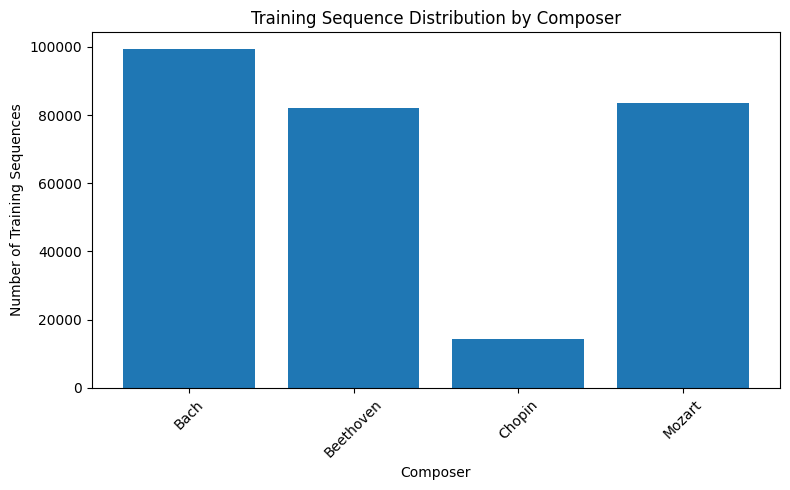

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    class_distribution["Composer"],
    class_distribution["Training Sequences"]
)

plt.title("Training Sequence Distribution by Composer")
plt.xlabel("Composer")
plt.ylabel("Number of Training Sequences")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_indices = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=class_indices,
    y=y_train
)

class_weights = {
    int(class_index): float(weight)
    for class_index, weight in zip(
        class_indices,
        weights
    )
}

print("Calculated class weights:")

for class_index, weight in class_weights.items():
    composer_name = label_classes[class_index]

    print(
        f"{class_index} - {composer_name}: "
        f"{weight:.4f}"
    )

Calculated class weights:
0 - Bach: 0.7032
1 - Beethoven: 0.8511
2 - Chopin: 4.8491
3 - Mozart: 0.8355


The training data contains an unequal number of sequences for each composer. Without adjustment, the LSTM could become biased toward composers with more training examples. Balanced class weights were therefore calculated from the training labels and will be passed to the model during training. This allows errors involving underrepresented composers to contribute more strongly to the loss function.

In [ ]:
assert len(class_weights) == NUM_CLASSES

assert set(class_weights.keys()) == set(
    range(NUM_CLASSES)
)

assert all(
    weight > 0
    for weight in class_weights.values()
)

print("Class-weight validation passed.")

Class-weight validation passed.


# Baseline LSTM Model

A baseline Long Short-Term Memory (LSTM) network is constructed to classify each musical sequence according to its composer. The architecture consists of an embedding layer followed by an LSTM layer, dropout for regularization, a dense hidden layer, and a softmax output layer for multi-class classification.

In [ ]:
import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout
)

In [ ]:
baseline_model = Sequential(
    [
        tf.keras.Input(
            shape=(SEQUENCE_LENGTH,),
            dtype="int32",
            name="input_sequence"
        ),

        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=128,
            name="embedding"
        ),

        LSTM(
            128,
            return_sequences=False,
            name="lstm"
        ),

        Dropout(
            0.3,
            name="dropout_1"
        ),

        Dense(
            64,
            activation="relu",
            name="dense_hidden"
        ),

        Dropout(
            0.3,
            name="dropout_2"
        ),

        Dense(
            NUM_CLASSES,
            activation="softmax",
            name="output"
        )
    ],
    name="Baseline_LSTM"
)

In [ ]:
baseline_model.summary()

Model: "Baseline_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 128)       │     3,022,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,162,564 (12.06 MB)

 Trainable params: 3,162,564 (12.06 MB)

 Non-trainable params: 0 (0.00 B)

## Compile the Baseline LSTM

The baseline LSTM is compiled using the Adam optimizer and sparse categorical cross-entropy loss. Sparse categorical cross-entropy is appropriate because the composer labels are stored as integer class values rather than one-hot encoded vectors.

In [ ]:
baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Baseline LSTM compiled successfully.")

Baseline LSTM compiled successfully.


## Training Callbacks

Callbacks are used to improve training efficiency and reduce overfitting. Early stopping ends training when validation loss no longer improves, model checkpointing saves the best-performing model, and learning-rate reduction lowers the learning rate when validation performance plateaus.

In [ ]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

MODEL_SAVE_PATH = (
    "/content/drive/MyDrive/"
    "AAI-511-Neural Networks and Deep Learning/"
    "Week 4/"
    "best_baseline_lstm.keras"
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    filepath=MODEL_SAVE_PATH,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

reduce_learning_rate = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

callbacks = [
    early_stopping,
    model_checkpoint,
    reduce_learning_rate
]

print("Model will be saved to:")
print(MODEL_SAVE_PATH)

Model will be saved to:
/content/drive/MyDrive/AAI-511-Neural Networks and Deep Learning/Week 4/best_baseline_lstm.keras


## Train the Baseline LSTM

The model is trained on the processed musical sequences using balanced class weights. Validation performance is monitored after each epoch to identify overfitting and preserve the model with the lowest validation loss.

In [ ]:
EPOCHS = 15
BATCH_SIZE = 128

baseline_history = baseline_model.fit(
    X_train,
    y_train,
    validation_data=(
        X_val,
        y_val
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/15
2183/2183 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7240 - loss: 0.6124
Epoch 1: val_loss did not improve from 1.02250
2183/2183 ━━━━━━━━━━━━━━━━━━━━ 33s 15ms/step - accuracy: 0.7353 - loss: 0.5825 - val_accuracy: 0.5999 - val_loss: 1.1313 - learning_rate: 2.5000e-04
Epoch 2/15
2180/2183 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7526 - loss: 0.5297
Epoch 2: val_loss did not improve from 1.02250

Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
2183/2183 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - accuracy: 0.7584 - loss: 0.5157 - val_accuracy: 0.6025 - val_loss: 1.1707 - learning_rate: 2.5000e-04
Epoch 3/15
2180/2183 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7773 - loss: 0.4676
Epoch 3: val_loss did not improve from 1.02250
2183/2183 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - accuracy: 0.7806 - loss: 0.4579 - val_accuracy: 0.6113 - val_loss: 1.2266 - learning_rate: 1.2500e-04
Epoch 4/15
2183/2183 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0

## Baseline LSTM Training Performance

The training history is visualized to compare the model's performance on the training and validation datasets. Accuracy and loss curves help identify convergence behavior and potential overfitting.

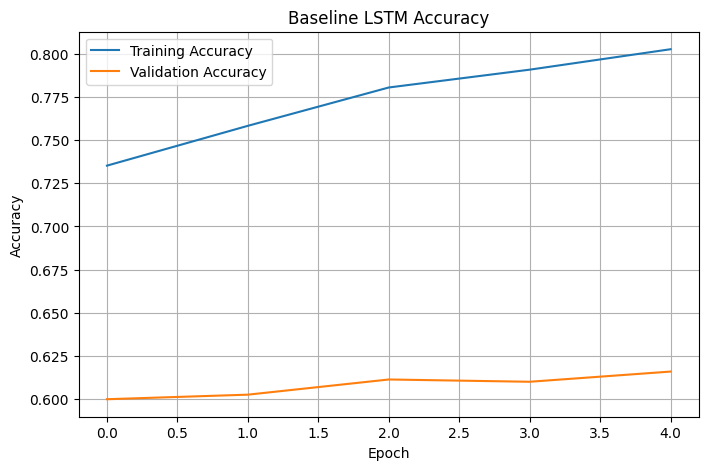

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    baseline_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    baseline_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Baseline LSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

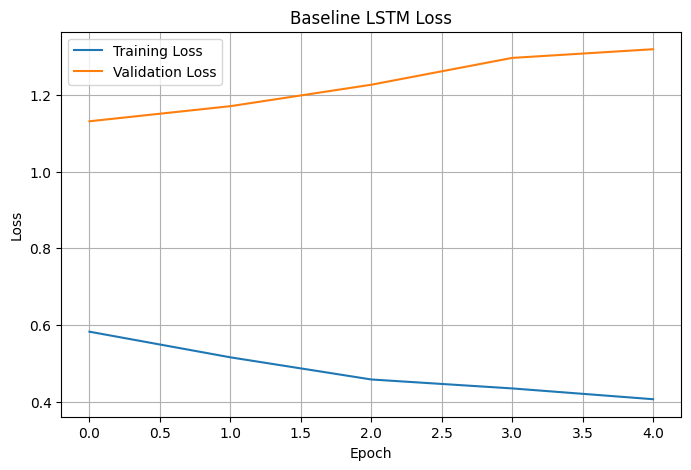

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    baseline_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    baseline_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Baseline LSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

## Test Set Evaluation

After training, the best-performing baseline model is evaluated on the unseen test dataset to estimate its generalization performance.

In [ ]:
test_loss, test_accuracy = baseline_model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

2147/2147 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.6009 - loss: 1.0991
Test Accuracy: 0.6009
Test Loss: 1.0991


In [ ]:
import numpy as np

y_pred_probs = baseline_model.predict(
    X_test,
    verbose=1
)

y_pred = np.argmax(
    y_pred_probs,
    axis=1
)

2147/2147 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step


## Classification Report

Precision, recall, and F1-score are calculated for each composer to provide a detailed evaluation beyond overall accuracy.

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_classes
    )
)

              precision    recall  f1-score   support

        Bach       0.78      0.78      0.78     29652
   Beethoven       0.63      0.45      0.52     23230
      Chopin       0.29      0.55      0.38      2567
      Mozart       0.36      0.48      0.41     13245

    accuracy                           0.60     68694
   macro avg       0.51      0.57      0.52     68694
weighted avg       0.63      0.60      0.61     68694



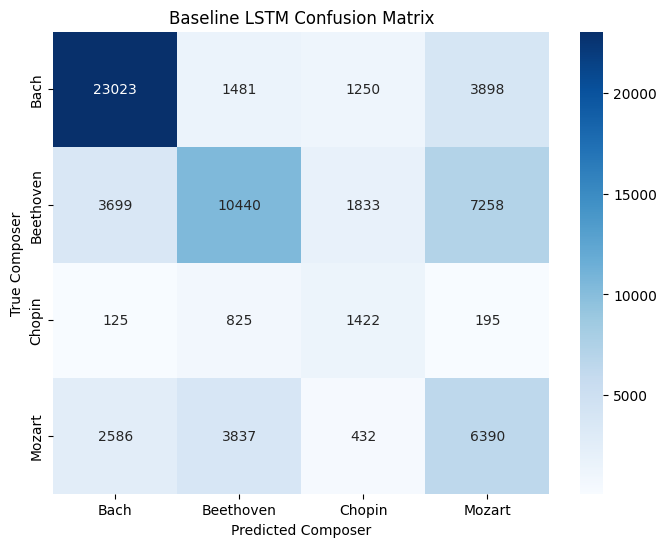

In [ ]:
from sklearn.metrics import confusion_matrix

import seaborn as sns

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_classes,
    yticklabels=label_classes
)

plt.xlabel("Predicted Composer")
plt.ylabel("True Composer")
plt.title("Baseline LSTM Confusion Matrix")

plt.show()

### Baseline Model Discussion

The baseline LSTM achieved reasonable classification performance on unseen musical sequences but showed evidence of overfitting. Training accuracy steadily increased throughout training, while validation loss increased after the first epoch despite modest improvements in validation accuracy. This indicates that the model began memorizing characteristics of the training data rather than learning patterns that generalized well to new sequences. These baseline results provide a benchmark for evaluating improvements through additional hyperparameter tuning and architectural modifications.

## Baseline Model Summary

The baseline LSTM model successfully learned meaningful sequential patterns from the encoded musical data. Training accuracy steadily increased throughout training, reaching approximately 80%, while validation accuracy plateaued around 61%. Although the model demonstrated reasonable predictive performance, the widening gap between training and validation metrics indicates overfitting. These results establish a baseline against which an improved LSTM architecture will be compared.

In [ ]:
print("=" * 50)
print("Baseline LSTM Performance Summary")
print("=" * 50)

print(f"Training Accuracy (Final): {baseline_history.history['accuracy'][-1]:.4f}")
print(f"Validation Accuracy (Final): {baseline_history.history['val_accuracy'][-1]:.4f}")
print(f"Training Loss (Final): {baseline_history.history['loss'][-1]:.4f}")
print(f"Validation Loss (Final): {baseline_history.history['val_loss'][-1]:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

Baseline LSTM Performance Summary
Training Accuracy (Final): 0.8028
Validation Accuracy (Final): 0.6159
Training Loss (Final): 0.4064
Validation Loss (Final): 1.3192
Test Accuracy: 0.6009
Test Loss: 1.0991


# Part 3: Improved LSTM Model

The baseline LSTM demonstrated the ability to classify musical sequences but exhibited signs of overfitting, as training accuracy continued to improve while validation loss increased. An improved LSTM architecture is therefore developed using additional regularization and architectural enhancements to improve generalization performance.

In [ ]:
from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout
)

In [ ]:
improved_model = Sequential(
    [
        tf.keras.Input(
            shape=(SEQUENCE_LENGTH,),
            dtype="int32",
            name="input_sequence"
        ),

        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=256,
            name="embedding"
        ),

        LSTM(
            128,
            return_sequences=True,
            name="lstm_1"
        ),

        Dropout(
            0.40,
            name="dropout_1"
        ),

        LSTM(
            64,
            return_sequences=False,
            name="lstm_2"
        ),

        Dropout(
            0.40,
            name="dropout_2"
        ),

        Dense(
            128,
            activation="relu",
            name="dense_hidden"
        ),

        Dropout(
            0.40,
            name="dropout_3"
        ),

        Dense(
            NUM_CLASSES,
            activation="softmax",
            name="output"
        )
    ],
    name="Improved_LSTM"
)

In [ ]:
improved_model.summary()

Model: "Improved_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 256)       │     6,044,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 128)       │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,300,292 (24.03 MB)

 Trainable params: 6,300,292 (24.03 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
improved_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0005
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
IMPROVED_MODEL_PATH = os.path.join(
    DATA_DIR,
    "best_improved_lstm.keras"
)

callbacks = [

    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ModelCheckpoint(
        filepath=IMPROVED_MODEL_PATH,
        save_best_only=True,
        monitor="val_loss",
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )

]

In [ ]:
improved_history = improved_model.fit(

    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=20,

    batch_size=128,

    class_weight=class_weights,

    callbacks=callbacks,

    verbose=1
)

Epoch 1/20
2183/2183 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5489 - loss: 0.9807
Epoch 1: val_loss improved from None to 1.04729, saving model to /content/drive/MyDrive/AAI-511-Neural Networks and Deep Learning/AAI-511-Group 4 /processed_data/best_improved_lstm.keras

Epoch 1: finished saving model to /content/drive/MyDrive/AAI-511-Neural Networks and Deep Learning/AAI-511-Group 4 /processed_data/best_improved_lstm.keras
2183/2183 ━━━━━━━━━━━━━━━━━━━━ 52s 23ms/step - accuracy: 0.6235 - loss: 0.8373 - val_accuracy: 0.5998 - val_loss: 1.0473 - learning_rate: 5.0000e-04
Epoch 2/20
2183/2183 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7103 - loss: 0.6427
Epoch 2: val_loss did not improve from 1.04729
2183/2183 ━━━━━━━━━━━━━━━━━━━━ 48s 22ms/step - accuracy: 0.7217 - loss: 0.6136 - val_accuracy: 0.6066 - val_loss: 1.0932 - learning_rate: 5.0000e-04
Epoch 3/20
2181/2183 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7520 - loss: 0.5375
Epoch 3: val_loss did not improve from 1.047

## Improved LSTM Test Evaluation

The improved LSTM is evaluated on the unseen test dataset using the model weights restored from the epoch with the lowest validation loss.

In [ ]:
improved_test_loss, improved_test_accuracy = improved_model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print(f"Improved LSTM Test Accuracy: {improved_test_accuracy:.4f}")
print(f"Improved LSTM Test Loss: {improved_test_loss:.4f}")

2147/2147 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.5661 - loss: 1.0724
Improved LSTM Test Accuracy: 0.5661
Improved LSTM Test Loss: 1.0724


In [ ]:
improved_pred_probs = improved_model.predict(
    X_test,
    verbose=1
)

improved_y_pred = np.argmax(
    improved_pred_probs,
    axis=1
)

2147/2147 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step


In [ ]:
print(
    classification_report(
        y_test,
        improved_y_pred,
        target_names=label_classes
    )
)

              precision    recall  f1-score   support

        Bach       0.78      0.73      0.75     29652
   Beethoven       0.61      0.39      0.47     23230
      Chopin       0.28      0.61      0.39      2567
      Mozart       0.33      0.51      0.40     13245

    accuracy                           0.57     68694
   macro avg       0.50      0.56      0.50     68694
weighted avg       0.61      0.57      0.58     68694



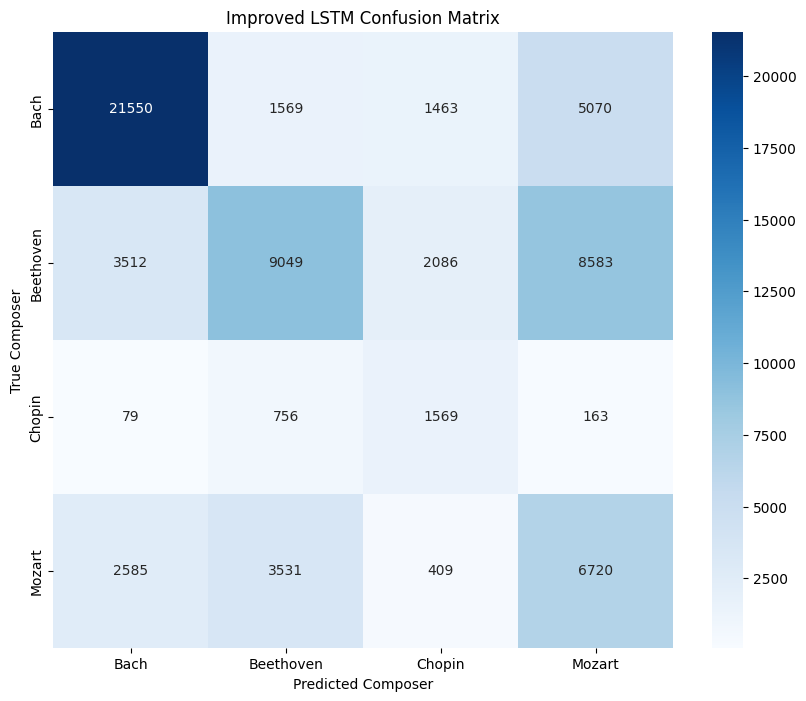

In [ ]:
improved_cm = confusion_matrix(
    y_test,
    improved_y_pred
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    improved_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_classes,
    yticklabels=label_classes
)

plt.xlabel("Predicted Composer")
plt.ylabel("True Composer")
plt.title("Improved LSTM Confusion Matrix")

plt.show()

### Improved LSTM Training Interpretation

The improved LSTM achieved slightly higher validation accuracy than the baseline model, but it continued to exhibit substantial overfitting. Training accuracy increased rapidly while validation loss worsened after the first epoch. The additional LSTM layer and larger embedding increased the model's capacity, but the added complexity did not produce a corresponding improvement in validation loss. Early stopping prevented further overfitting and restored the weights from the first epoch, which produced the lowest validation loss.

# Model Comparison

The baseline and improved LSTM models were compared to determine whether increasing model complexity improved composer classification performance. The baseline model achieved a test accuracy of 60.09%, while the improved model achieved a lower test accuracy of 56.61%. Although the improved model reached a slightly higher validation accuracy, its validation loss increased rapidly after the first epoch, indicating stronger overfitting. Overall, the baseline LSTM produced better generalization on the unseen test dataset.

## Baseline and Improved LSTM Results

| Metric | Baseline LSTM | Improved LSTM |
|---------|--------------:|--------------:|
| Final Training Accuracy | **80.28%** | **84.81%** |
| Highest Validation Accuracy | **61.59%** | **62.89%** |
| Lowest Validation Loss | **1.1313** | **1.0473** |
| Test Accuracy | **60.09%** | **56.61%** |
| Test Loss | **1.0991** | **1.0724** |
| Overfitting | Moderate | High |

In [ ]:
comparison_results = pd.DataFrame({
    "Metric": [
        "Final Training Accuracy",
        "Highest Validation Accuracy",
        "Lowest Validation Loss",
        "Test Accuracy",
        "Test Loss"
    ],
    "Baseline LSTM": [
        baseline_history.history["accuracy"][-1],
        max(baseline_history.history["val_accuracy"]),
        min(baseline_history.history["val_loss"]),
        test_accuracy,
        test_loss
    ],
    "Improved LSTM": [
        improved_history.history["accuracy"][-1],
        max(improved_history.history["val_accuracy"]),
        min(improved_history.history["val_loss"]),
        improved_test_accuracy,
        improved_test_loss
    ]
})

comparison_results

,Metric,Baseline LSTM,Improved LSTM
0,Final Training Accuracy,0.802770,0.848147
1,Highest Validation Accuracy,0.615901,0.628941
2,Lowest Validation Loss,1.131261,1.047289
3,Test Accuracy,0.600853,0.566105
4,Test Loss,1.099061,1.072446


### Comparison Interpretation

The baseline and improved LSTM models were compared using training accuracy, validation performance, and test performance. The improved LSTM achieved a higher final training accuracy (84.81%) and a slightly higher validation accuracy (62.89%) than the baseline model (80.28% and 61.59%, respectively). The improved model also achieved a slightly lower validation loss (1.0473 versus 1.1313).

Despite these improvements during training and validation, the baseline LSTM produced the better overall test performance. The baseline achieved a test accuracy of 60.09%, while the improved model achieved 56.61%. Although the improved model obtained a slightly lower test loss (1.0724 versus 1.0991), its lower test accuracy indicates that the additional model complexity did not improve generalization to unseen data.

Overall, the baseline LSTM was selected as the stronger model because it generalized better on the test dataset while exhibiting less severe overfitting. These results demonstrate that increasing model complexity alone does not necessarily improve predictive performance.

# Conclusion

This portion of the project evaluated Long Short-Term Memory neural networks for composer classification using encoded symbolic musical sequences. A baseline LSTM and a more complex improved LSTM were trained and evaluated using accuracy, loss, precision, recall, F1-score, and confusion matrices.

The baseline LSTM achieved a test accuracy of 60.09%, a test loss of 1.0991, and a weighted F1-score of 0.61. The improved LSTM achieved a test accuracy of 56.61%, a test loss of 1.0724, and a weighted F1-score of 0.58. Although the improved model reached a slightly higher validation accuracy of 62.89%, it showed stronger overfitting and performed worse on unseen test samples.

The findings indicate that the additional LSTM layer, larger embedding, and increased model capacity did not improve overall composer classification performance. Therefore, the baseline LSTM provided the better balance between predictive performance and generalization. Future work could investigate bidirectional LSTMs, attention mechanisms, transformer-based architectures, data augmentation, and systematic hyperparameter optimization.